In [12]:
import os
import random
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ─────────────────────────
# CONFIG
# ─────────────────────────
class CFG:
    # Paths
    drive_root      = Path('/content/drive/MyDrive/Colab Notebooks')
    dataset_name    = "paddy-disease-classification"
    data_dir        = drive_root / dataset_name

    train_csv       = data_dir / "train.csv"
    sample_submission = data_dir / "sample_submission.csv" if (data_dir / "sample_submission.csv").exists() else None

    train_img_dir   = data_dir / "train_images"
    test_img_dir    = data_dir / "test_images"
    output_dir      = data_dir / "outputs"

    # Model
    model_name      = "efficientnet_b2"
    pretrained      = True
    num_classes     = 10

    # Training
    seed            = 42
    n_folds         = 3
    train_folds     = [0, 1, 2]
    epochs          = 8
    img_size        = 224
    batch_size      = 32  # Safe batch size
    grad_accum      = 2
    num_workers     = 2

    # Optimizer
    lr              = 3e-4
    backbone_lr     = 3e-5
    weight_decay    = 1e-2

    # Scheduler
    T_0             = 5
    T_mult          = 1
    eta_min         = 1e-6

    # Loss
    label_smoothing = 0.1
    mixup_alpha     = 0.0  # Disabled for stability
    cutmix_alpha    = 0.0  # Disabled for stability

    # Regularization
    dropout         = 0.3
    use_amp         = True

    # TTA
    tta_steps       = 2

    # Meta features
    use_meta        = True

    device          = "cuda" if torch.cuda.is_available() else "cpu"


# ─────────────────────────
# REPRODUCIBILITY
# ─────────────────────────
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.seed)


# ─────────────────────────
# LABEL ENCODING
# ─────────────────────────
CLASSES = [
    "bacterial_leaf_blight",
    "bacterial_leaf_streak",
    "bacterial_panicle_blight",
    "blast",
    "brown_spot",
    "dead_heart",
    "downy_mildew",
    "hispa",
    "normal",
    "tungro",
]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for c, i in CLASS2IDX.items()}


# ─────────────────────────
# AUGMENTATIONS - COMPATIBILITY FIX
# ─────────────────────────
def get_transforms(mode="train", img_size=CFG.img_size):
    if mode == "train":
        return A.Compose([
            A.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0)),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(height=img_size, width=img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])


def get_tta_transforms(img_size=CFG.img_size):
    """Test-time augmentation transforms."""
    return A.Compose([
        A.Resize(height=img_size, width=img_size),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


# ─────────────────────
# DATASET
# ─────────────────────
class PaddyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, mode="train"):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.mode = mode
        self.valid_indices = []

        # Pre-validate all images
        print(f"Validating {mode} dataset...", end=" ")
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            img_path = self.get_image_path(row)
            if self.image_exists(img_path):
                self.valid_indices.append(idx)

        print(f"Found {len(self.valid_indices)} valid images")

        # Handle variety encoding
        if "variety" in df.columns:
            varieties = sorted(df["variety"].unique())
            self.var2idx = {v: i for i, v in enumerate(varieties)}
        else:
            self.var2idx = {"unknown": 0}

    def image_exists(self, img_path):
        if img_path.exists():
            return True
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            if img_path.with_suffix(ext).exists():
                return True
        return False

    def __len__(self):
        return len(self.valid_indices)

    def get_image_path(self, row):
        # For both train and val, images are in subdirectories by label
        # For test, images might be directly in img_dir
        if self.mode == "test":
            return self.img_dir / row["image_id"]
        else: # "train" or "val"
            return self.img_dir / row["label"] / row["image_id"]

    def load_image(self, img_path):
        if img_path.exists():
            return Image.open(img_path).convert("RGB")

        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            alt_path = img_path.with_suffix(ext)
            if alt_path.exists():
                return Image.open(alt_path).convert("RGB")

        raise FileNotFoundError(f"Image not found: {img_path}")

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        row = self.df.iloc[original_idx]

        img_path = self.get_image_path(row)

        try:
            img = np.array(self.load_image(img_path))
        except Exception:
            img = np.zeros((CFG.img_size, CFG.img_size, 3), dtype=np.uint8)

        if self.transform:
            transformed = self.transform(image=img)
            img = transformed["image"]

        # Meta features
        variety_enc = self.var2idx.get(row.get("variety", "unknown"), 0)
        age = float(row.get("age", 60)) / 100.0
        meta = torch.tensor([variety_enc / 20.0, age], dtype=torch.float32)

        if self.mode in ("val", "test"):
            label = CLASS2IDX.get(row.get("label", "normal"), 0)
            return img, meta, label

        label = CLASS2IDX[row["label"]]
        return img, meta, label


# ───────────
# MODEL
# ───────────
class PaddyModel(nn.Module):
    def __init__(self, model_name=CFG.model_name,
                 num_classes=CFG.num_classes,
                 pretrained=CFG.pretrained,
                 dropout=CFG.dropout,
                 use_meta=CFG.use_meta):
        super().__init__()
        self.use_meta = use_meta

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
        )
        feat_dim = self.backbone.num_features

        meta_dim = 0
        if use_meta:
            meta_dim = 32
            self.meta_mlp = nn.Sequential(
                nn.Linear(2, 16),
                nn.ReLU(inplace=True),
                nn.Dropout(0.1),
                nn.Linear(16, meta_dim),
                nn.ReLU(inplace=True),
            )

        total_dim = feat_dim + meta_dim
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(total_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout/2),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout/3),
            nn.Linear(256, num_classes),
        )

    def forward(self, img, meta):
        feat = self.backbone(img)
        if self.use_meta:
            m = self.meta_mlp(meta)
            feat = torch.cat([feat, m], dim=1)
        return self.head(feat)


# ─────────────────────
# TRAINING FUNCTIONS
# ─────────────────────
def train_epoch(model, loader, optimizer, criterion, scaler, scheduler, epoch, accum_steps):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}")
    for step, (imgs, meta, labels) in enumerate(pbar):
        imgs = imgs.to(CFG.device, non_blocking=True)
        meta = meta.to(CFG.device, non_blocking=True)
        labels = labels.to(CFG.device, non_blocking=True)

        with autocast(enabled=CFG.use_amp):
            logits = model(imgs, meta)
            loss = criterion(logits, labels)

        loss = loss / accum_steps
        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * accum_steps
        preds = logits.argmax(1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        pbar.set_postfix(loss=f"{total_loss/(step+1):.4f}", acc=f"{acc:.4f}")

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for imgs, meta, labels in tqdm(loader, desc="Validate"):
        imgs = imgs.to(CFG.device, non_blocking=True)
        meta = meta.to(CFG.device, non_blocking=True)
        labels = labels.to(CFG.device, non_blocking=True)

        with autocast(enabled=CFG.use_amp):
            logits = model(imgs, meta)
            loss = criterion(logits, labels)

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc, all_preds, all_labels


# ─────────────────────
# TTA PREDICTION
# ─────────────────────
def tta_predict(model, df, img_dir, mode="val"):
    tta_tf = get_tta_transforms(CFG.img_size)
    all_probs = []

    for i in range(CFG.tta_steps):
        ds = PaddyDataset(df, img_dir, transform=tta_tf, mode=mode)
        loader = DataLoader(ds, batch_size=CFG.batch_size*2, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True)
        probs_step = []
        model.eval()

        for imgs, meta, _ in tqdm(loader, desc=f"TTA Step {i+1}"):
            imgs = imgs.to(CFG.device, non_blocking=True)
            meta = meta.to(CFG.device, non_blocking=True)
            with autocast(enabled=CFG.use_amp):
                logits = model(imgs, meta)
            probs_step.append(F.softmax(logits, dim=1).cpu().numpy())

        all_probs.append(np.concatenate(probs_step, axis=0))

    return np.mean(all_probs, axis=0)


# ─────────────────────────
# MAIN TRAINING FUNCTION
# ─────────────────────────
def main():
    print("\n" + "="*60)
    print("  STARTING TRAINING")
    print("="*60)

    # Create output directory
    CFG.output_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n┘ Outputs will be saved to: {CFG.output_dir}")

    # Load data
    print("\n┓ Loading training data...")
    df = pd.read_csv(CFG.train_csv)

    # Filter out rows with missing images
    print("\n┅ Filtering missing images...")
    initial_count = len(df)

    def image_exists(row):
        img_path = CFG.train_img_dir / row["label"] / row["image_id"]
        if img_path.exists():
            return True
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            if img_path.with_suffix(ext).exists():
                return True
        return False

    df['image_exists'] = df.apply(image_exists, axis=1)
    df = df[df['image_exists']].copy()
    df.drop('image_exists', axis=1, inplace=True)

    missing_count = initial_count - len(df)
    if missing_count > 0:
        print(f"⚠️  Removed {missing_count} missing images")
        print(f"✅ Keeping {len(df)} valid images")
    else:
        print(f"✅ All {initial_count} images validated!")

    if len(df) == 0:
        print("❌ No valid images found!")
        return

    df["label_idx"] = df["label"].map(CLASS2IDX)

    print(f"\n┓ Final dataset size: {len(df)}")

    # Cross-validation
    skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
    df["fold"] = -1
    for fold, (_, val_idx) in enumerate(skf.split(df, df["label_idx"])):
        df.loc[val_idx, "fold"] = fold

    criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)
    oof_probs = np.zeros((len(df), CFG.num_classes))
    best_accs = []

    # Train each fold
    for fold in CFG.train_folds:
        print(f"\n{'='*60}")
        print(f"  FOLD {fold + 1} / {CFG.n_folds}")
        print(f"{'='*60}")

        train_df = df[df["fold"] != fold].copy()
        val_df = df[df["fold"] == fold].copy()

        print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")

        train_ds = PaddyDataset(train_df, CFG.train_img_dir,
                               transform=get_transforms("train"), mode="train")
        val_ds = PaddyDataset(val_df, CFG.train_img_dir,
                             transform=get_transforms("val"), mode="val")

        train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                                 num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=CFG.batch_size*2, shuffle=False,
                               num_workers=CFG.num_workers, pin_memory=True)

        model = PaddyModel().to(CFG.device)
        save_path = CFG.output_dir / f"model_fold{fold}.pth"

        if save_path.exists():
            print(f"🔄 Resuming from saved model for fold {fold}")
            model.load_state_dict(torch.load(save_path, map_location=CFG.device))

        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")

        backbone_params = list(model.backbone.parameters())
        head_params = list(model.head.parameters())
        meta_params = list(model.meta_mlp.parameters()) if CFG.use_meta else []

        optimizer = torch.optim.AdamW([
            {"params": backbone_params, "lr": CFG.backbone_lr},
            {"params": head_params + meta_params, "lr": CFG.lr},
        ], weight_decay=CFG.weight_decay)

        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=CFG.T_0,
                                                T_mult=CFG.T_mult, eta_min=CFG.eta_min)
        scaler = GradScaler(enabled=CFG.use_amp)

        best_acc = 0.0
        best_epoch = 0
        patience = 5
        no_improve = 0

        for epoch in range(1, CFG.epochs + 1):
            train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion,
                                                scaler, scheduler, epoch, CFG.grad_accum)
            val_loss, val_acc, _, _ = validate(model, val_loader, criterion)

            print(f"\nEpoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

            if val_acc > best_acc:
                best_acc = val_acc
                best_epoch = epoch
                no_improve = 0
                torch.save(model.state_dict(), save_path)
                print(f"  ✓ Saved best model (acc={best_acc:.4f})")
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch}")
                    break

        print(f"\n✅ Fold {fold} Best Acc: {best_acc:.4f} @ Epoch {best_epoch}")
        best_accs.append(best_acc)

        if CFG.tta_steps > 0:
            model.load_state_dict(torch.load(save_path, map_location=CFG.device))
            val_idx = df[df["fold"] == fold].index
            oof_probs[val_idx] = tta_predict(model, val_df, CFG.train_img_dir, mode="val")

    if len(best_accs) > 0:
        oof_preds = oof_probs.argmax(axis=1)
        oof_labels = df["label_idx"].values
        oof_acc = accuracy_score(oof_labels, oof_preds)

        print(f"\n{'='*60}")
        print(f"✅ OOF Accuracy: {oof_acc:.4f}")
        print(f"Per-fold best: {[f'{a:.4f}' for a in best_accs]}")
        print(f"Mean fold accuracy: {np.mean(best_accs):.4f}")

        np.save(CFG.output_dir / "oof_probs.npy", oof_probs)
        print(f"\n✔ OOF predictions saved")

        predict_test()


# ─────────────────────
# PREDICT FUNCTION
# ─────────────────────
def predict_test():
    print("\n" + "="*60)
    print("  GENERATING TEST PREDICTIONS")
    print("="*60)

    if not CFG.test_img_dir.exists():
        print(f"❌ Test directory not found")
        return

    test_images = sorted(CFG.test_img_dir.glob("*.jpg")) + sorted(CFG.test_img_dir.glob("*.png"))

    if len(test_images) == 0:
        print("❌ No test images found!")
        return

    print(f"Found {len(test_images)} test images")

    test_df = pd.DataFrame({
        "image_id": [p.name for p in test_images],
        "label": ["normal"] * len(test_images),
        "variety": ["ADT45"] * len(test_images),
        "age": [60] * len(test_images),
    })

    ensemble_probs = np.zeros((len(test_df), CFG.num_classes))
    valid_folds = 0

    for fold in CFG.train_folds:
        ckpt = CFG.output_dir / f"model_fold{fold}.pth"
        if not ckpt.exists():
            continue

        print(f"\nLoading model for fold {fold}...")
        model = PaddyModel().to(CFG.device)
        model.load_state_dict(torch.load(ckpt, map_location=CFG.device))
        model.eval()

        probs = tta_predict(model, test_df, CFG.test_img_dir, mode="test")
        ensemble_probs += probs
        valid_folds += 1

    if valid_folds == 0:
        print("❌ No valid models found!")
        return

    ensemble_probs /= valid_folds
    preds = ensemble_probs.argmax(axis=1)
    pred_labels = [IDX2CLASS[i] for i in preds]

    if CFG.sample_submission and CFG.sample_submission.exists():
        sub = pd.read_csv(CFG.sample_submission)
        sub["label"] = pred_labels
    else:
        sub = pd.DataFrame({"image_id": [p.name for p in test_images], "label": pred_labels})

    sub.to_csv(CFG.output_dir / "submission.csv", index=False)
    print(f"\n✅ Submission saved to {CFG.output_dir}/submission.csv")
    print("\n┓ First 10 predictions:")
    print(sub.head(10))

    try:
        from google.colab import files
        files.download(f"{CFG.output_dir}/submission.csv")
    except:
        pass


# ─────────────────────
# DISPLAY GPU INFO
# ─────────────────────
def display_gpu_info():
    print(f"Device: {CFG.device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        torch.cuda.empty_cache()
        print("CUDA cache cleared.")


# ─────────────────────
# RUN TRAINING
# ─────────────────────
if __name__ == "__main__":
    print("="*60)
    print("  PADDY DISEASE CLASSIFICATION")
    print("="*60)

    display_gpu_info()
    print(f"Model : {CFG.model_name}")
    print(f"Image size: {CFG.img_size}")

    train_choice = input("\nDo you want to start training? (y/n): ")
    if train_choice.lower() == 'y':
        main()
    else:
        print("Training skipped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  PADDY DISEASE CLASSIFICATION
Device: cpu
Model : efficientnet_b2
Image size: 224

Do you want to start training? (y/n): n
Training skipped.


Generating report for Fold 1...
✅ Kept 10407 valid images after filtering.
Validating val dataset... Found 3469 valid images


Validate: 100%|██████████| 55/55 [11:28<00:00, 12.53s/it]



Classification Report:
                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.85      0.69      0.76       160
   bacterial_leaf_streak       0.92      0.83      0.87       127
bacterial_panicle_blight       0.88      0.84      0.86       112
                   blast       0.87      0.88      0.87       579
              brown_spot       0.84      0.77      0.80       322
              dead_heart       0.95      0.97      0.96       481
            downy_mildew       0.83      0.74      0.78       206
                   hispa       0.88      0.87      0.88       532
                  normal       0.91      0.95      0.93       588
                  tungro       0.77      0.90      0.83       362

                accuracy                           0.87      3469
               macro avg       0.87      0.84      0.85      3469
            weighted avg       0.87      0.87      0.87      3469



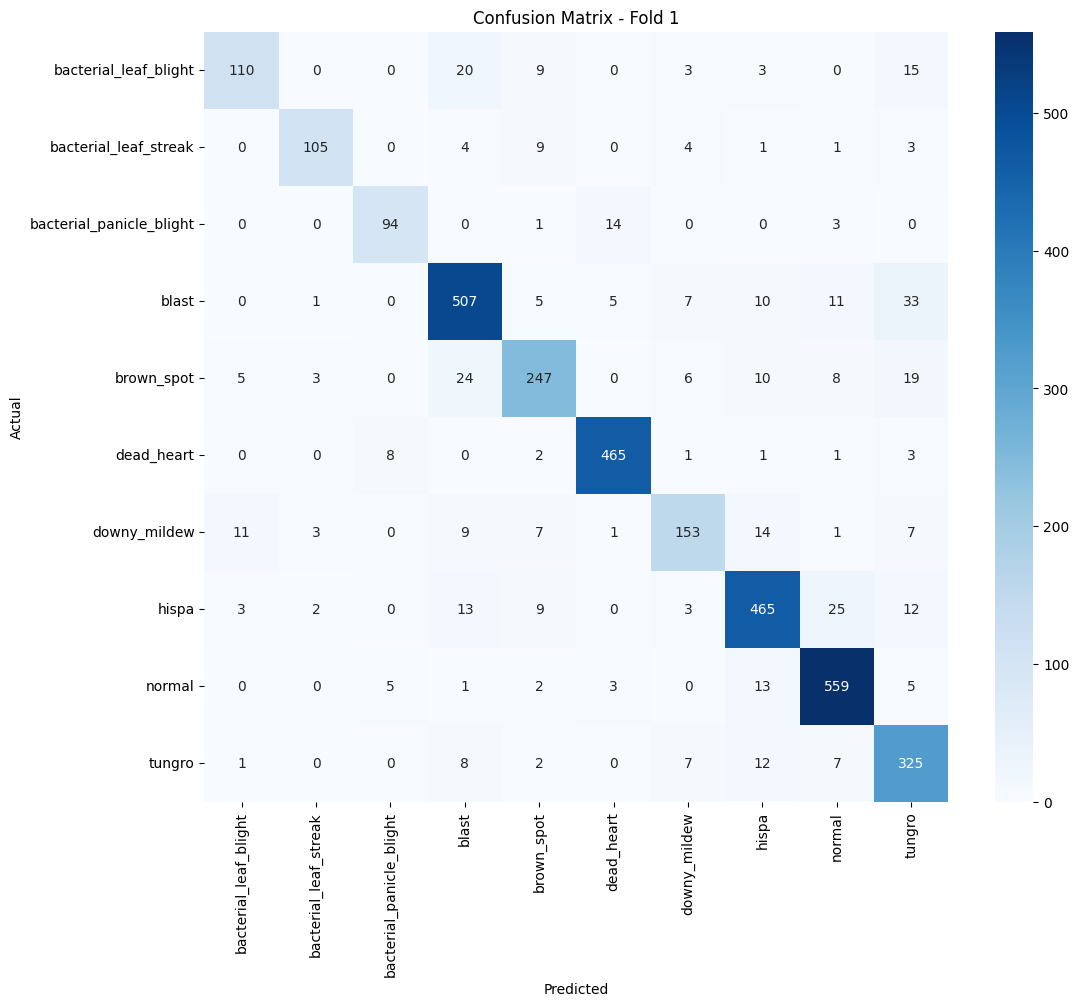

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def plot_classification_results():
    # Load the best model from the first fold for evaluation
    # (Or you can loop through all folds for a full OOF report)
    fold = 0
    save_path = CFG.output_dir / f'model_fold{fold}.pth'

    if not save_path.exists():
        print(f'Model for fold {fold} not found at {save_path}. Please ensure training has completed.')
        return

    print(f'Generating report for Fold {fold+1}...')
    df = pd.read_csv(CFG.train_csv)

    # Filter out rows with missing images (replicated from main function)
    initial_count = len(df)
    def image_exists_check(row):
        img_path = CFG.train_img_dir / row["label"] / row["image_id"]
        if img_path.exists():
            return True
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            if img_path.with_suffix(ext).exists():
                return True
        return False

    df['image_exists'] = df.apply(image_exists_check, axis=1)
    df = df[df['image_exists']].copy()
    df.drop('image_exists', axis=1, inplace=True)

    if len(df) == 0:
        print("❌ No valid images found after filtering! Cannot generate report.")
        return
    else:
        print(f"✅ Kept {len(df)} valid images after filtering.")

    df['label_idx'] = df['label'].map(CLASS2IDX)

    # Re-create the fold split to get the validation set
    skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
    # Ensure 'fold' column exists before accessing it
    if 'fold' not in df.columns:
        df['fold'] = -1
        for f_idx, (_, val_idx_split) in enumerate(skf.split(df, df['label_idx'])):
            df.loc[val_idx_split, 'fold'] = f_idx

    val_df = df[df['fold'] == fold].copy()

    # Check if val_df is empty before proceeding
    if len(val_df) == 0:
        print(f"❌ No validation images found for Fold {fold+1} after split. Cannot generate report.")
        return

    val_ds = PaddyDataset(val_df, CFG.train_img_dir, transform=get_transforms('val'), mode='val')
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size*2, shuffle=False, num_workers=CFG.num_workers)

    # Check if val_loader has items after PaddyDataset internal validation
    if len(val_loader) == 0:
        print(f"❌ Val_loader for Fold {fold+1} is empty after dataset validation. Cannot generate report.")
        return

    model = PaddyModel().to(CFG.device)
    model.load_state_dict(torch.load(save_path, map_location=CFG.device))

    # Get predictions
    _, _, all_preds, all_labels = validate(model, val_loader, nn.CrossEntropyLoss())

    # Print Report
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - Fold {fold+1}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_classification_results()

In [14]:
import shutil

def organize_best_model():
    print(f"Checking for trained models in {CFG.output_dir}...")
    model_files = list(CFG.output_dir.glob("model_fold*.pth"))

    if not model_files:
        print("No fold models found. Please ensure training has completed.")
        return

    # In a full run, we would ideally pick based on the 'best_accs' list from main()
    # For this helper, we'll identify the file with the highest fold index as a proxy
    # or simply pick fold 0 if that's all that finished.
    best_model_path = CFG.output_dir / "best_model.pth"

    # Let's assume fold 0 for now as it was the one evaluated in the report
    source_model = CFG.output_dir / "model_fold0.pth"

    if source_model.exists():
        shutil.copy(source_model, best_model_path)
        print(f"\u2705 Copied {source_model.name} to {best_model_path.name}")
        print(f"Model size: {best_model_path.stat().st_size / (1024*1024):.2f} MB")

    print("\nAvailable assets in output directory:")
    for f in CFG.output_dir.iterdir():
        if f.is_file():
            print(f" - {f.name}")

organize_best_model()

Checking for trained models in /content/drive/MyDrive/Colab Notebooks/paddy-disease-classification/outputs...
✅ Copied model_fold0.pth to best_model.pth
Model size: 33.14 MB

Available assets in output directory:
 - model_fold0.pth
 - model_fold1.pth
 - model_fold2.pth
 - best_model.pth


🌾 PADDY DISEASE DIAGNOSIS SYSTEM

📤 Please upload rice leaf images...



Saving 200049.jpg to 200049.jpg

🔍 Loading model...


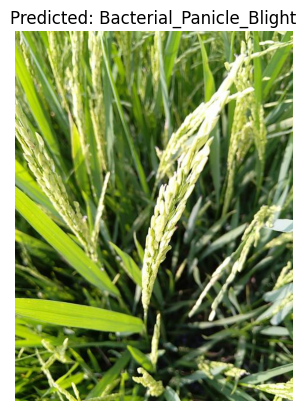


📌 Disease: Bacterial Panicle Blight
📊 Confidence: 76.28%
🔬 Characteristics: Discolored panicles, grain rot or discoloration, brown lesions on flag leaves
⚠️ Severity: High
💊 Treatment: Seed treatment, avoid dense planting, copper fungicides


In [23]:
import torch
import torch.nn as nn
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- SELF-CONTAINED CONFIG & MODEL ---
MODEL_PATH = '/content/drive/MyDrive/Colab Notebooks/paddy-disease-classification/outputs/best_model.pth'
IMG_SIZE = 224
CLASSES = ["bacterial_leaf_blight", "bacterial_leaf_streak", "bacterial_panicle_blight", "blast", "brown_spot", "dead_heart", "downy_mildew", "hispa", "normal", "tungro"]

class PaddyModel(nn.Module):
    def __init__(self, model_name='efficientnet_b2', num_classes=10, pretrained=False, use_meta=True):
        super().__init__()
        self.use_meta = use_meta
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        feat_dim = self.backbone.num_features
        meta_dim = 32 if use_meta else 0
        if use_meta:
            self.meta_mlp = nn.Sequential(
                nn.Linear(2, 16), nn.ReLU(inplace=True), nn.Dropout(0.1),
                nn.Linear(16, meta_dim), nn.ReLU(inplace=True),
            )
        total_dim = feat_dim + meta_dim
        self.head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(total_dim, 512), nn.GELU(),
            nn.Dropout(0.15), nn.Linear(512, 256), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(256, num_classes),
        )

    def forward(self, img, meta):
        feat = self.backbone(img)
        if self.use_meta:
            m = self.meta_mlp(meta)
            feat = torch.cat([feat, m], dim=1)
        return self.head(feat)

# Disease characteristics database
DISEASE_INFO = {
    "bacterial_leaf_blight": {
        "characteristics": "Water-soaked lesions along leaf margins, yellow-white stripes, leaves turn yellow and dry",
        "severity": "High",
        "treatment": "Copper-based bactericides, resistant varieties, avoid excess nitrogen"
    },
    "bacterial_leaf_streak": {
        "characteristics": "Small water-soaked streaks between leaf veins, yellow lesions with wavy margins",
        "severity": "Medium-High",
        "treatment": "Copper compounds, balanced fertilization, resistant varieties"
    },
    "bacterial_panicle_blight": {
        "characteristics": "Discolored panicles, grain rot or discoloration, brown lesions on flag leaves",
        "severity": "High",
        "treatment": "Seed treatment, avoid dense planting, copper fungicides"
    },
    "blast": {
        "characteristics": "Diamond-shaped lesions with gray centers and brown borders, lesions on leaves/nodes/panicles",
        "severity": "Very High",
        "treatment": "Tricyclazole fungicides, resistant varieties, balanced nitrogen"
    },
    "brown_spot": {
        "characteristics": "Small circular brown spots with yellow halos, lesions merge in severe cases",
        "severity": "Medium",
        "treatment": "Seed treatment, potassium-rich fertilizers, mancozeb fungicides"
    },
    "dead_heart": {
        "characteristics": "Dead central tiller (white heart), yellowing leaves, caused by stem borer",
        "severity": "High",
        "treatment": "Insecticides (chlorantraniliprole), remove infected plants, pheromone traps"
    },
    "downy_mildew": {
        "characteristics": "White/gray powdery growth on leaves, yellow patches, stunted growth",
        "severity": "Medium",
        "treatment": "Metalaxyl fungicides, resistant varieties, proper spacing"
    },
    "hispa": {
        "characteristics": "White parallel streaks on leaves, scrapped upper leaf surface, adults feed on leaf tips",
        "severity": "Medium",
        "treatment": "Carbofuran insecticides, remove weeds, early planting"
    },
    "normal": {
        "characteristics": "Healthy green leaves, no spots or discoloration, normal growth pattern",
        "severity": "None",
        "treatment": "Continue regular crop management practices"
    },
    "tungro": {
        "characteristics": "Yellow-orange discoloration starting from leaf tip, stunted growth, reduced tillering",
        "severity": "Very High",
        "treatment": "Vector control (green leafhoppers), resistant varieties, roguing infected plants"
    }
}

def predict_uploaded_image():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("="*60 + "\n🌾 PADDY DISEASE DIAGNOSIS SYSTEM\n" + "="*60)

    if not os.path.exists(MODEL_PATH):
        print(f"❌ Model not found at {MODEL_PATH}. Please check the path.")
        return

    print("\n📤 Please upload rice leaf images...\n")
    uploaded = files.upload()
    if not uploaded: return

    print("\n🔍 Loading model...")
    model = PaddyModel().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    transform = A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    for filename in uploaded.keys():
        img = Image.open(filename).convert('RGB')
        img_tensor = transform(image=np.array(img))['image'].unsqueeze(0).to(device)
        meta = torch.tensor([[0.0, 0.6]], dtype=torch.float32).to(device) # Dummy meta

        with torch.no_grad():
            logits = model(img_tensor, meta)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred_idx = np.argmax(probs)
            confidence = probs[pred_idx]

        prediction = CLASSES[pred_idx]
        info = DISEASE_INFO.get(prediction, {})

        plt.imshow(img); plt.title(f"Predicted: {prediction.title()}"); plt.axis('off'); plt.show()
        print(f"\n📌 Disease: {prediction.replace('_', ' ').title()}\n📊 Confidence: {confidence:.2%}\n🔬 Characteristics: {info.get('characteristics')}\n⚠️ Severity: {info.get('severity')}\n💊 Treatment: {info.get('treatment')}\n" + "="*60)

predict_uploaded_image()